# Vector compression — token study + book search

**Survey:** JL projections, rank-k SVD, sign/scalar quantization — see `docs/PAPER.md` and `docs/SURVEY.md`.

**Part A:** 230 word embeddings (toy nearest-neighbor demo + recall vs bits).

**Part B:** Index **[Prof. Wang's MATH 5110 Quarto book](https://github.com/wanghemath/Book-AdvancedLinearAlgebraAI)** (~1380 chunks). RAG hit@k uses labeled queries in `python/data/rag_queries.yaml`.

**Part C — live demo:** Open the web UI (`bun run dev` → http://localhost:5173) or run the search cell below. Compare `full_precision` vs `sign_1bit` in the UI.

Requires `.env` with `AZURE_OPENAI_*`. CLI fallback: `uv run python scripts/search_class.py "your question"`

In [8]:
%matplotlib inline

import sys
from pathlib import Path

import polars as pl
from IPython.display import display, Markdown


def find_repo() -> Path:
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("Open this notebook from the repo (e.g. python/notebooks/)")


REPO = find_repo()
src = str(REPO / "python" / "src")
if src not in sys.path:
    sys.path.insert(0, src)

# Jupyter caches imports — drop stale vector_linalg after git pull / edits
for name in list(sys.modules):
    if name == "vector_linalg" or name.startswith("vector_linalg."):
        del sys.modules[name]

from vector_linalg.config import load_config
from vector_linalg.embeddings import embedding_matrix, fetch_token_embeddings
from vector_linalg.metrics import results_table
from vector_linalg.plots import (
    figure_distance_error,
    figure_rag_compare,
    figure_recall_vs_bits,
    figure_token_pca,
)
from vector_linalg.rag import fetch_rag_embeddings, run_rag_compression_study, search_corpus
from vector_linalg.study import run_compression_study

cfg = load_config()
provider = cfg.embeddings.provider
display(Markdown(f"Repo: `{cfg.repo_root}` | embeddings: **{provider}** | RAG source: **{cfg.rag.source}**"))

Repo: `C:\Users\tclay\Documents\Projects\math5110-portfolio-linalg` | embeddings: **azure** | RAG source: **github_book**

## Part A — Token embedding compression (toy universe)

In [9]:
df = fetch_token_embeddings(cfg)
tokens, keys = embedding_matrix(df)
dim = keys.shape[1]
display(Markdown(f"**{len(tokens)}** tokens, **d={dim}** (`{cfg.embeddings.model}` via {provider})"))
display(df.select(["token", "d0", "d1", "d2", "d3"]).head(8))

**230** tokens, **d=256** (`text-embedding-3-small` via azure)

token,d0,d1,d2,d3
str,f64,f64,f64,f64
"""the""",-0.002838,-0.007935,0.039856,0.057648
"""a""",0.054565,0.017731,-0.018585,0.054016
"""is""",-0.064453,0.025146,0.039673,0.040588
"""are""",-0.009514,-0.038116,0.05661,0.087891
"""was""",-0.051697,0.002161,-0.002151,0.012688
"""be""",0.078003,0.016693,0.018661,0.049835
"""have""",0.008621,0.007744,0.019958,0.026138
"""do""",0.008904,0.006596,-0.037537,0.09906


In [10]:
token_results = run_compression_study(keys, cfg)
display(results_table(token_results, cfg.recall_k))

method,bits_per_dim,compression_ratio,mean_distance_rel_error,recall_at_10
str,f64,f64,f64,f64
"""full_precision""",32.0,1.0,3.1093e-8,1.0
"""scalar_8bit""",8.0,4.0,0.000303,0.996667
"""scalar_4bit""",4.0,8.0,0.006876,0.958333
"""rank_64""",16.904348,1.893004,0.099781,0.883333
"""scalar_2bit""",2.0,16.0,0.143471,0.825
…,…,…,…,…
"""jl_128""",16.0,2.0,0.048817,0.591667
"""jl_64""",8.0,4.0,0.076002,0.5
"""rank_8""",2.113043,15.144033,0.537754,0.453333


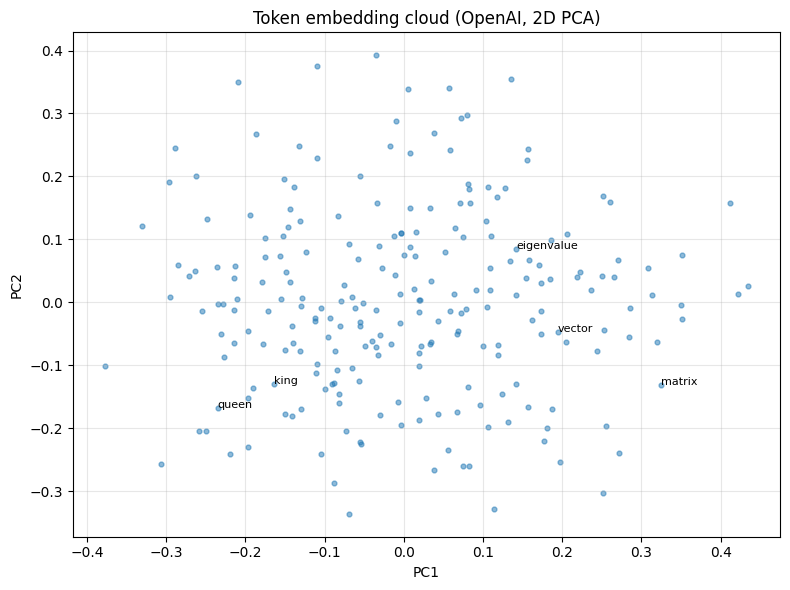

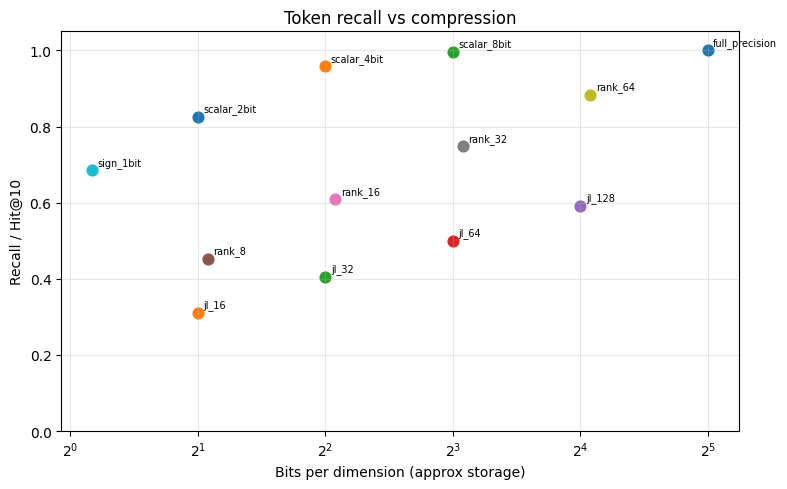

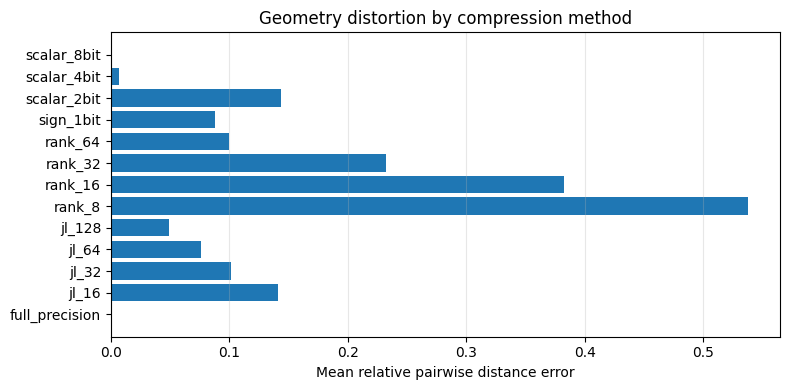

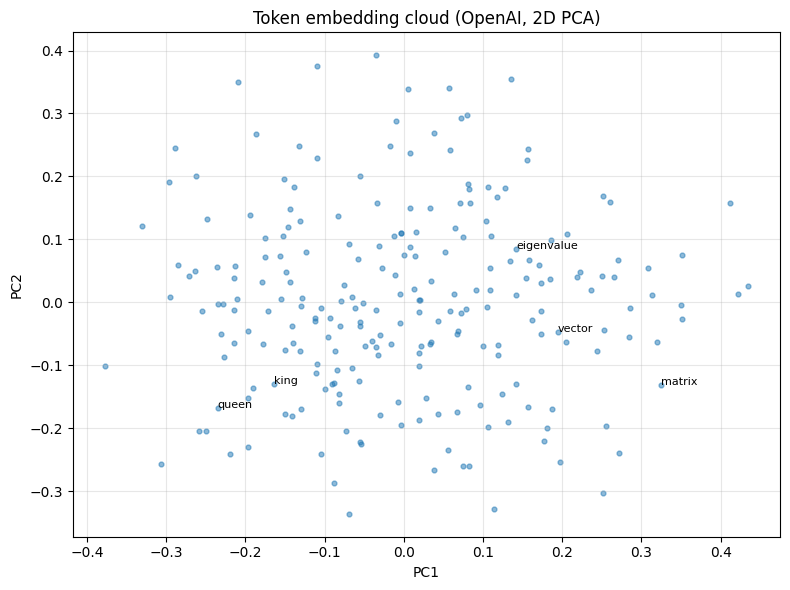

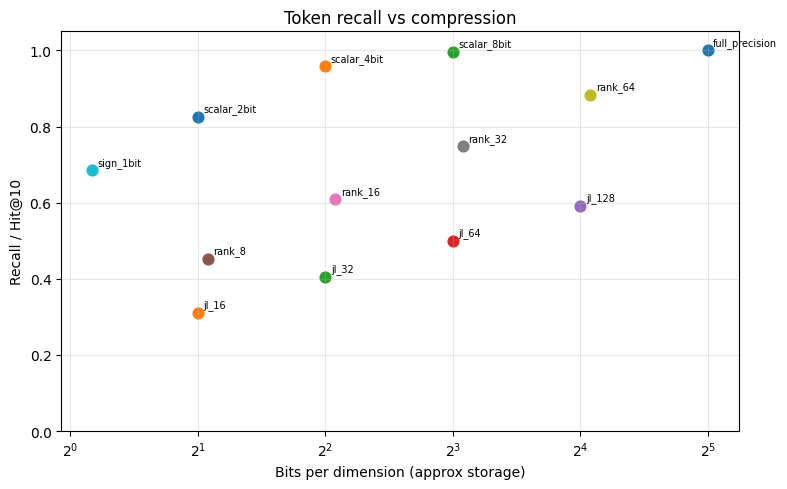

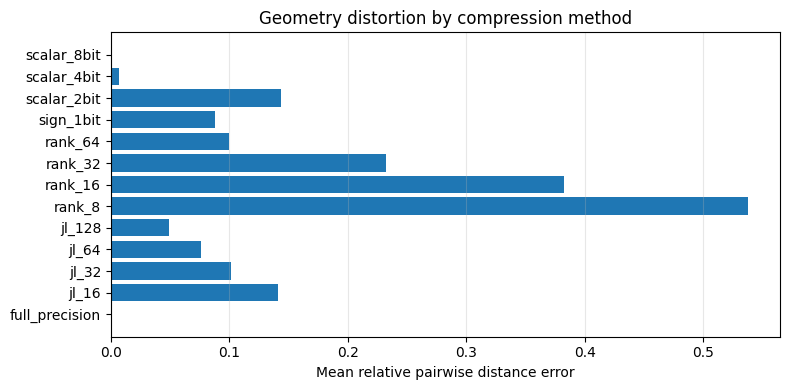

In [11]:
display(figure_token_pca(keys, tokens, highlight=["king", "queen", "matrix", "vector", "eigenvalue"]))
display(figure_recall_vs_bits(token_results, cfg.recall_k, title="Token recall vs compression"))
display(figure_distance_error(token_results))

## Part B — RAG on MATH 5110 book (GitHub Quarto source)

Pipeline:
1. Fetch `chapters/*.qmd` from [Book-AdvancedLinearAlgebraAI](https://github.com/wanghemath/Book-AdvancedLinearAlgebraAI)
2. Strip Quarto markup → chunk by `##` sections
3. Embed chunks → compress index → measure hit@k

Canvas PDFs (`rag.source: canvas`) are optional but lecture slides are often image-heavy math.

In [12]:
if not cfg.rag.enabled:
    display(Markdown("RAG disabled in config.yaml"))
else:
    rag_bundle = fetch_rag_embeddings(cfg)
    n_chunks = len(rag_bundle.chunk_ids)
    n_queries = len(rag_bundle.query_texts)
    display(Markdown(f"**{n_chunks}** chunks from Canvas PDFs, **{n_queries}** eval queries"))

    sample = pl.DataFrame({
        "chunk_id": rag_bundle.chunk_ids[:5],
        "preview": [t[:120] + "..." for t in rag_bundle.chunk_texts[:5]],
    })
    display(sample)

  Skipped 12 queries with stale chunk ids (label rag_queries.yaml later).
  Using synthetic hold-out queries (first 200 chars of sample chunks).


**1380** chunks from Canvas PDFs, **12** eval queries

chunk_id,preview
str,str
"""chapter-01-linear-systems_c000""","""> **Guiding question.** > How …"
"""chapter-01-linear-systems_c001""","""n with linear systems, then in…"
"""chapter-01-linear-systems_c002""","""## 1.1 Linear systems as quest…"
"""chapter-01-linear-systems_c003""","""j occur. A **linear system** o…"
"""chapter-01-linear-systems_c004""","""ots & a_{mn} \end{bmatrix}\in …"


method,bits_per_dim,compression_ratio,mean_distance_rel_error,recall_at_3
str,f64,f64,f64,f64
"""full_precision""",32.0,1.0,3.1273e-8,1.0
"""jl_16""",2.0,16.0,0.146924,1.0
"""jl_32""",4.0,8.0,0.10105,1.0
"""jl_64""",8.0,4.0,0.068906,1.0
"""jl_128""",16.0,2.0,0.054605,1.0
…,…,…,…,…
"""scalar_2bit""",2.0,16.0,0.204347,1.0
"""scalar_4bit""",4.0,8.0,0.009576,1.0
"""scalar_8bit""",8.0,4.0,0.000378,1.0


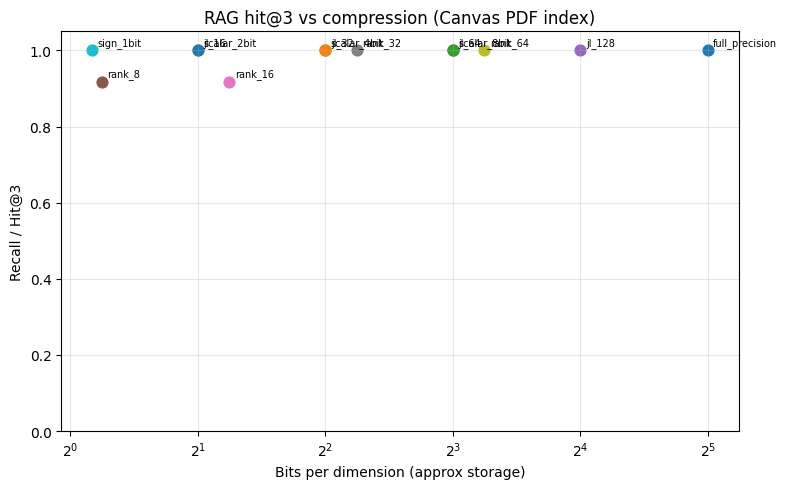

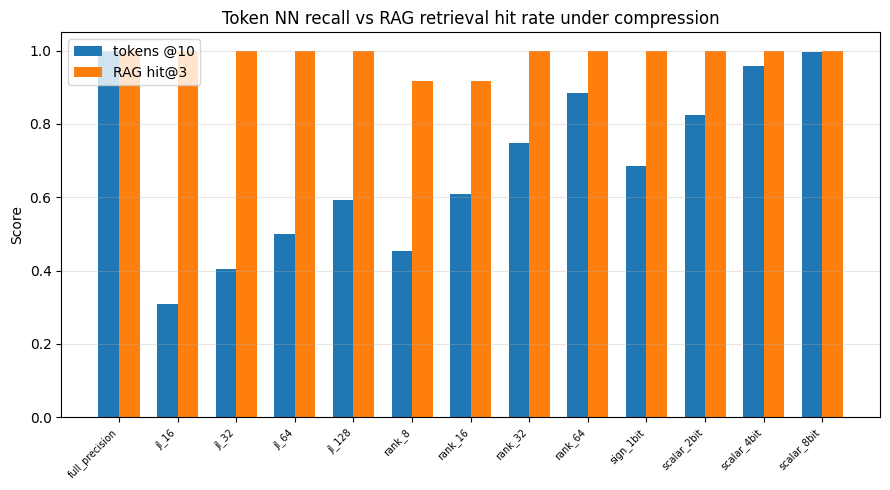

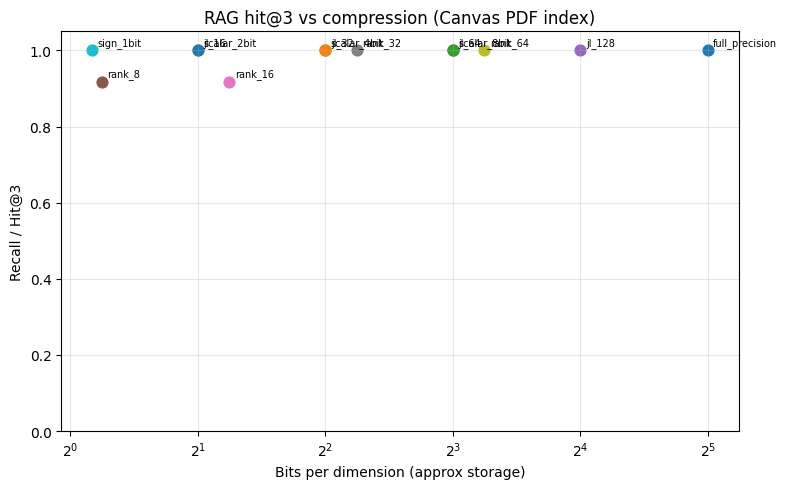

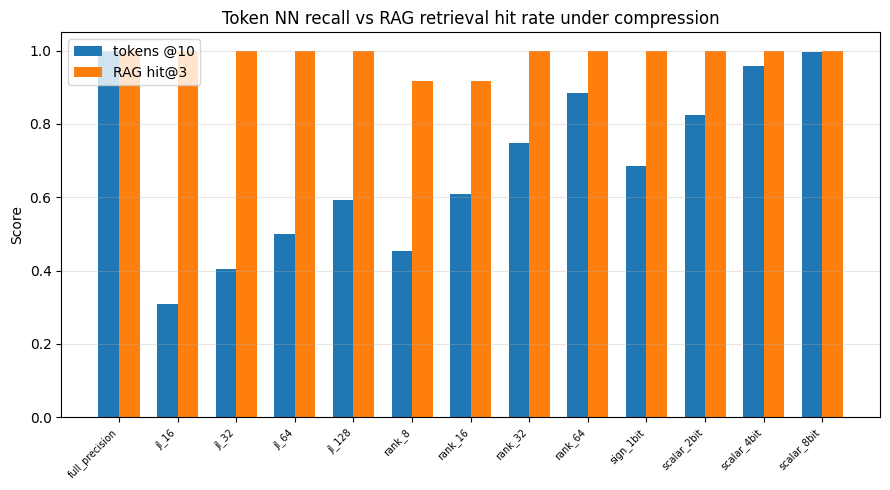

In [13]:
if cfg.rag.enabled:
    rag_results = run_rag_compression_study(rag_bundle, cfg)
    display(results_table(rag_results, cfg.rag.recall_k))

    display(figure_recall_vs_bits(
        rag_results,
        cfg.rag.recall_k,
        title=f"RAG hit@{cfg.rag.recall_k} vs compression (book index)",
    ))
    display(figure_rag_compare(
        token_results,
        rag_results,
        token_k=cfg.recall_k,
        rag_k=cfg.rag.recall_k,
    ))

## Part C — Search the book (interactive RAG)

Embed a question and retrieve the closest textbook chunks. **Retrieval only** — no LLM answer step.

- **Notebook:** edit `QUESTION` below and run the cell.
- **Web UI (demo):** `uv sync --directory backend`, then `bun run dev` → http://localhost:5173 — storage table, KaTeX math, compare indexes.

In [14]:
QUESTION = "What is the spectral theorem for symmetric matrices?"

if cfg.rag.enabled:
    for hit in search_corpus(QUESTION, rag_bundle, cfg, top_k=3):
        display(Markdown(f"**#{hit.rank}** (score {hit.score:.3f}) — `{hit.chunk_id}`"))
        display(Markdown(hit.text[:600] + ("..." if len(hit.text) > 600 else "")))

  embedded 1/1


**#1** (score 0.693) — `chapter-09-dynamical-systems-markov-chains-perron-frobenius_c020`

## Theorem 9.11: Perron--Frobenius theorem, primitive case Let A\ge0 be primitive. Then: 1. A has a positive real eigenvalue \rho(A)>0 , called the **Perron eigenvalue** or **spectral radius**. 2. There is a positive eigenvector v>0 such that Av=\rho(A)v. 3. The eigenvalue \rho(A) is simple and strictly dominates all other eigenvalues in modulus. 4. For many initial vectors x_0\ge0 , the normalized iterates A^k x_0/\|A^k x_0\|_1 converge to the normalized Perron eigenvector. <details> <summary>Proof idea</summary> The full proof is deeper than ordinary diagonalization. The core idea is that po...

**#2** (score 0.636) — `chapter-history-linear-algebra-timeline_c026`

## 10.3 Perron--Frobenius Theory For matrices with positive entries, the Perron--Frobenius theorem gives a dominant positive eigenvalue and positive eigenvector. This appears in: - Markov chains, - population models, - network centrality, - PageRank. --- # 11. Symmetric Matrices and the Spectral Theorem A real matrix A is symmetric if A^T=A. The spectral theorem states that a real symmetric matrix can be orthogonally diagonalized: A=QDQ^T. Here Q is orthogonal and D is diagonal.

**#3** (score 0.561) — `chapter-20-hilbert-spaces-applications_c017`

## Proof Consider the partial Taylor polynomials p_m(x)=\sum_{k=0}^{m}\frac{x^k}{k!}. For n>m , p_n-p_m=\sum_{k=m+1}^{n}\frac{x^k}{k!}. Using the triangle inequality in the L^2 norm, \|p_n-p_m\|_{L^2} \le \sum_{k=m+1}^{n} \left\|\frac{x^k}{k!}\right\|_{L^2}. But \left\|\frac{x^k}{k!}\right\|_{L^2} = \frac{1}{k!} \left(\int_0^1 x^{2k}\,dx\right)^{1/2} = \frac{1}{k!\sqrt{2k+1}}. The series \sum_{k=0}^{\infty}\frac{1}{k!\sqrt{2k+1}} converges. Hence (p_m) is Cauchy in the L^2 norm. However, p_m\to e^x uniformly on [0,1] , hence also in L^2[0,1] . The function e^x is not a polynomial. Therefore th...